#Exploratory Data Analysis (EDA)

##**1. Setup & Data Loading**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('cleaned_data_fraud.csv')

print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isna().sum().sum()}")
df.describe().T

Shape: (594643, 8)

Data types:
step          int64
customer     object
age          object
gender       object
merchant     object
category     object
amount      float64
fraud         int64
dtype: object

Missing values:
0


,count,mean,std,min,25%,50%,75%,max
step,594643.0,94.986827,51.053632,0.0,52.00,97.0,139.00,179.00
amount,594643.0,37.890135,111.402831,0.0,13.74,26.9,42.54,8329.96
fraud,594643.0,0.012108,0.109369,0.0,0.00,0.0,0.00,1.00


In [11]:
df

,step,customer,age,gender,merchant,category,amount,fraud
0,0,C1093826151,4,M,M348934600,es_transportation,4.55,0
1,0,C352968107,2,M,M348934600,es_transportation,39.68,0
2,0,C2054744914,4,F,M1823072687,es_transportation,26.89,0
3,0,C1760612790,3,M,M348934600,es_transportation,17.25,0
4,0,C757503768,5,M,M348934600,es_transportation,35.72,0
...,...,...,...,...,...,...,...,...
594638,179,C1753498738,3,F,M1823072687,es_transportation,20.53,0
594639,179,C650108285,4,F,M1823072687,es_transportation,50.73,0
594640,179,C123623130,2,F,M349281107,es_fashion,22.44,0
594641,179,C1499363341,5,M,M1823072687,es_transportation,14.46,0


In [18]:
df['step'].value_counts()

,count
step,
175,3774
177,3758
152,3746
174,3743
178,3743
...,...
5,2525
3,2499
2,2462


**The data has already been cleaned in 01_data_cleaning.ipynb**

##**2. Target Variabel Distribution**

fraud
0    587443
1      7200
Name: count, dtype: int64
fraud
0    98.789189
1     1.210811
Name: proportion, dtype: float64


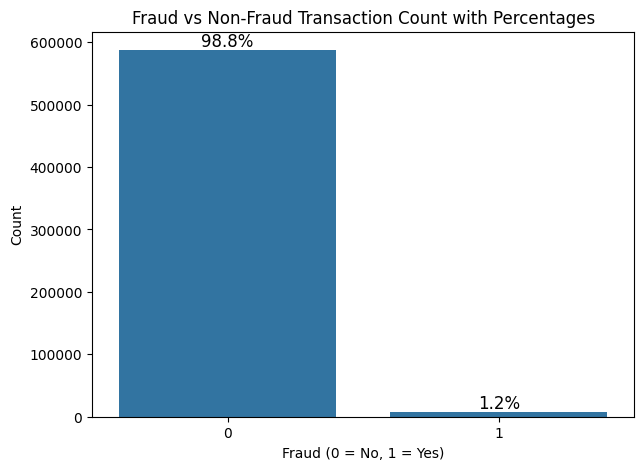

In [10]:
import os

print(df['fraud'].value_counts())
print(df['fraud'].value_counts(normalize=True) * 100)

# Create the directory if it doesn't exist
output_dir = 'outputs/figures'
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(7, 5)) # Adjust figure size for better readability of annotations
sns.countplot(data=df, x='fraud')

# Add percentage annotations on top of the bars
total = len(df['fraud'])
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Fraud vs Non-Fraud Transaction Count with Percentages')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig(os.path.join(output_dir, '01_target_distribution_with_percentages.png'), dpi=150, bbox_inches='tight')
plt.show()

### Section 2: Target Distribution — Interpretation

**Result**: The dataset contains 594,643 transactions, of which 587,443
(98.79%) are legitimate and 7,200 (1.21%) are fraudulent.

**Interpretation**: This confirms a significant class imbalance, with
fraudulent transactions representing roughly 1 in every 83 transactions.
While not as extreme as some fraud datasets (e.g. <0.2% fraud rate), the
imbalance is still severe enough that a naive model predicting "non-fraud"
for every transaction would achieve 98.79% accuracy while being
completely useless for fraud detection.

**Modeling Implications**:
- **Accuracy is not a valid evaluation metric** for this problem; metrics
  such as Precision-Recall AUC, Recall, and F1-score will be prioritized
  instead, as they better reflect performance on the minority (fraud) class.
- **Class imbalance handling is required** before training — this will be
  addressed in the modeling stage (Notebook 04) through resampling
  techniques (e.g. SMOTE) and/or algorithm-level adjustments
  (`class_weight='balanced'`).
- **Stratified sampling must be used** for the train-test split to ensure
  the fraud class proportion is preserved in both subsets, preventing a
  test set with too few (or zero) fraud cases to evaluate on reliably.
- **Threshold tuning** will be necessary at the evaluation stage, since
  the default classification threshold of 0.5 is generally suboptimal
  for imbalanced classification problems.

##**3. Univariate Analysis - Categorical Columns**

In [15]:
print(df['gender'].value_counts())
print(df['gender'].value_counts(normalize=True) * 100)
print()
print(df['age'].value_counts())
print(df['age'].value_counts(normalize=True) * 100)
print()
print(df['category'].value_counts())
print(df['category'].value_counts(normalize=True) * 100)

gender
F    324565
M    268385
E      1178
U       515
Name: count, dtype: int64
gender
F    54.581488
M    45.133803
E     0.198102
U     0.086607
Name: proportion, dtype: float64

age
2    187310
3    147131
4    109025
5     62642
1     58131
6     26774
0      2452
U      1178
Name: count, dtype: int64
age
2    31.499572
3    24.742745
4    18.334530
5    10.534388
1     9.775781
6     4.502533
0     0.412348
U     0.198102
Name: proportion, dtype: float64

category
es_transportation        505119
es_food                   26254
es_health                 16133
es_wellnessandbeauty      15086
es_fashion                 6454
es_barsandrestaurants      6373
es_hyper                   6098
es_sportsandtoys           4002
es_tech                    2370
es_home                    1986
es_hotelservices           1744
es_otherservices            912
es_contents                 885
es_travel                   728
es_leisure                  499
Name: count, dtype: int64
category
es_transpo

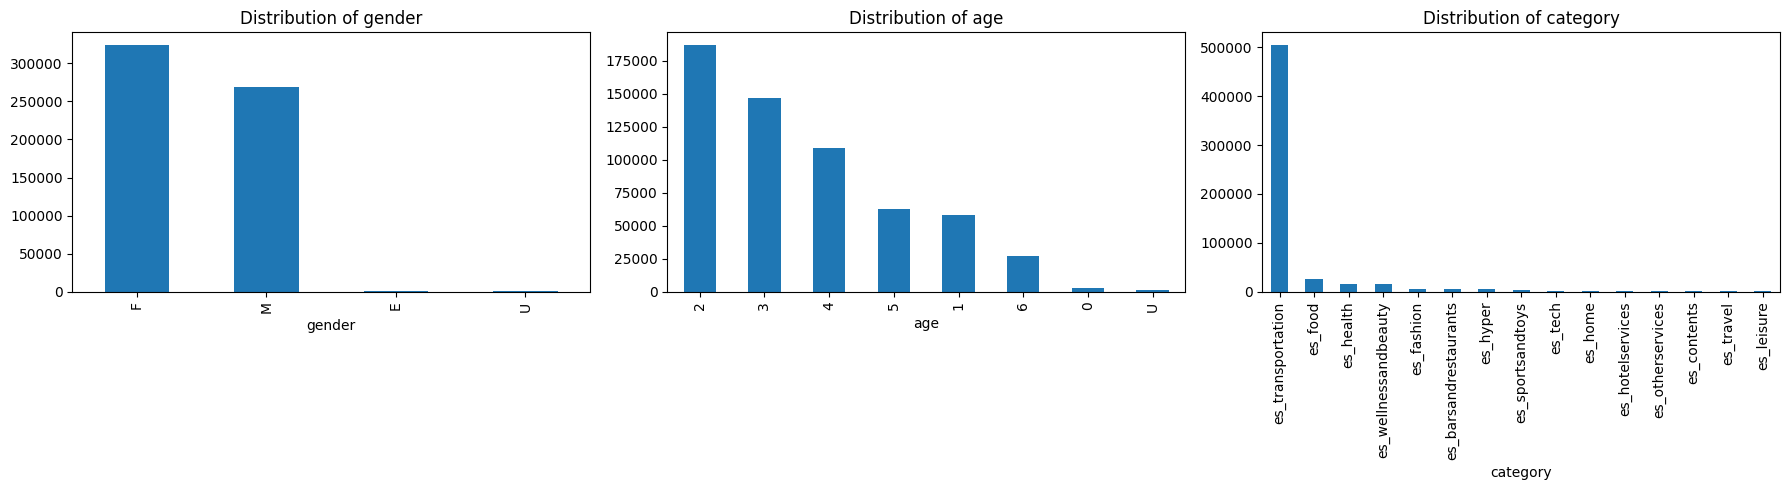

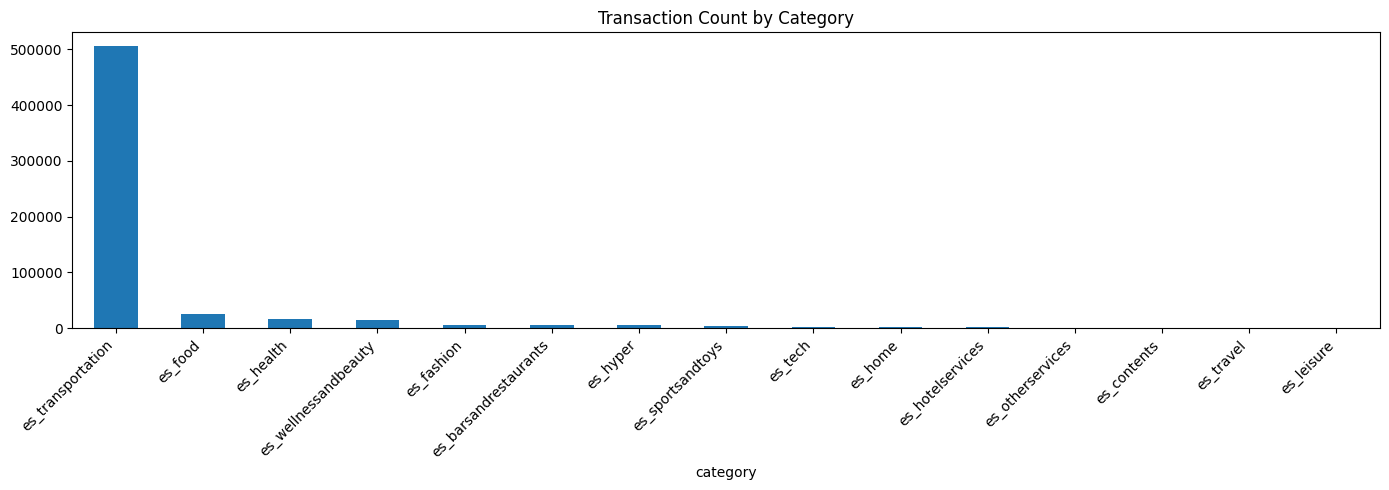

In [16]:
categorical_cols = ['gender', 'age', 'category']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('outputs/figures/02_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 5))
df['category'].value_counts().plot(kind='bar')
plt.title('Transaction Count by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Section 3: Univariate Analysis — Categorical Columns (Interpretation)

**Gender**: The distribution is moderately imbalanced toward female
customers (54.58% F vs. 45.13% M), with two additional categories — `E`
(0.20%) and `U`, unknown (0.09%) — representing a negligible share of
transactions. No single gender category dominates overwhelmingly, so
gender is unlikely to cause severe sparsity issues during encoding,
though the `E` and `U` categories will have very few observations to
learn from.

**Age**: Age groups `2` and `3` together account for over 56% of all
transactions, with a fairly smooth decline toward the older bins (`5`,
`6`) and younger bin (`0`). The `U` (unknown) category is extremely rare
(0.20%), suggesting missing/unknown age is not a widespread data quality
issue — just a small number of edge cases. The distribution resembles a
typical customer base concentrated in early-to-mid adulthood age bins.

**Category**: This is the most skewed of the three columns by a wide
margin. `es_transportation` alone accounts for **84.94%** of all
transactions, while the remaining 14 categories collectively make up
just ~15%. Several categories (`es_travel`, `es_leisure`, `es_contents`,
`es_otherservices`) each represent less than 0.2% of total volume.

**Modeling Implications**:
- **Category is heavily imbalanced in volume**, independent of the fraud
  imbalance already noted. This means fraud-rate estimates for
  low-volume categories (e.g. `es_leisure`, 499 transactions) will be
  statistically less reliable than for high-volume categories like
  `es_transportation` — this distinction must be kept in mind when
  interpreting Section 4's fraud-rate-by-category results, and should
  be stated explicitly rather than treating all category fraud rates as
  equally trustworthy.
- **One-hot encoding remains feasible** for `category`, `gender`, and
  `age` given their manageable cardinality (15, 4, and 8 unique values
  respectively), unlike `customer` and `merchant` which require
  frequency/target encoding due to much higher cardinality.
- **Rare categories** (`E`, `U` in gender; `0`, `U` in age; several
  low-volume categories) may need to be monitored during
  train-test split to ensure they appear in both sets, or consolidated
  into an "other" bucket if they cause instability during modeling.

## **4. Univariate Analysis - Numeric Analysis**

count    594643.000000
mean         37.890135
std         111.402831
min           0.000000
25%          13.740000
50%          26.900000
75%          42.540000
max        8329.960000
Name: amount, dtype: float64


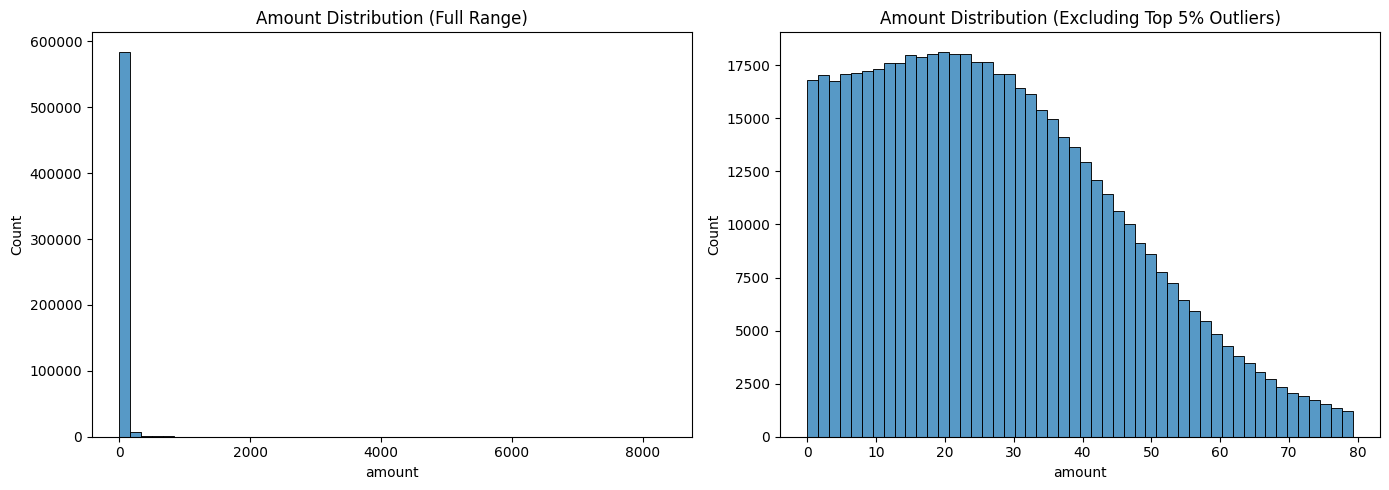

Amount skewness: 32.37


In [17]:
print(df['amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['amount'], bins=50, ax=axes[0])
axes[0].set_title('Amount Distribution (Full Range)')

sns.histplot(df[df['amount'] < df['amount'].quantile(0.95)]['amount'], bins=50, ax=axes[1])
axes[1].set_title('Amount Distribution (Excluding Top 5% Outliers)')
plt.tight_layout()
plt.savefig('outputs/figures/03_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Check skewness
from scipy.stats import skew
print(f"Amount skewness: {skew(df['amount']):.2f}")

### Section 4: Univariate Analysis — Amount (Interpretation)

**Interpretation**: The vast majority of transactions are small-value
(75% of transactions are below 42.54), while a small number of very
large transactions (up to 8,329.96) pull the mean far above the median
and typical range. This is a classic long-tail pattern common in
financial transaction data, where most spending is routine and low-value,
but rare high-value transactions exist and disproportionately affect
summary statistics.

**Modeling Implications**:
- **Log transformation is necessary** before feeding `amount` into
  distance-based or linear models (e.g. Logistic Regression), as the
  extreme skew can distort coefficient estimates and make the feature's
  effect harder to interpret. Tree-based models (Random Forest, XGBoost)
  are less sensitive to skew, but a log-transformed version is still
  useful for consistency and for feature engineering (e.g. ratio-based
  features).
- **Outliers at the high end are not necessarily errors** — given the
  natural long-tail nature of transaction amounts, high-value
  transactions should not be removed without first checking their fraud
  association (to be examined in Section 6, `amount` vs. `fraud`).
- **Standard scaling should be applied after log transformation**, not
  on the raw `amount` values, to avoid the extreme range (0–8,329.96)
  disproportionately influencing models sensitive to feature scale.
- This confirms the log-transform decision already planned for
  `03_feature_engineering.ipynb` (`amount_log = np.log1p(amount)`).

##**5. Fraud Rate by Category**

                       fraud_rate  transaction_count
category                                            
es_leisure               0.949900                499
es_travel                0.793956                728
es_sportsandtoys         0.495252               4002
es_hotelservices         0.314220               1744
es_otherservices         0.250000                912
es_home                  0.152064               1986
es_health                0.105126              16133
es_tech                  0.066667               2370
es_wellnessandbeauty     0.047594              15086
es_hyper                 0.045917               6098
es_barsandrestaurants    0.018829               6373
es_fashion               0.017973               6454
es_contents              0.000000                885
es_food                  0.000000              26254
es_transportation        0.000000             505119


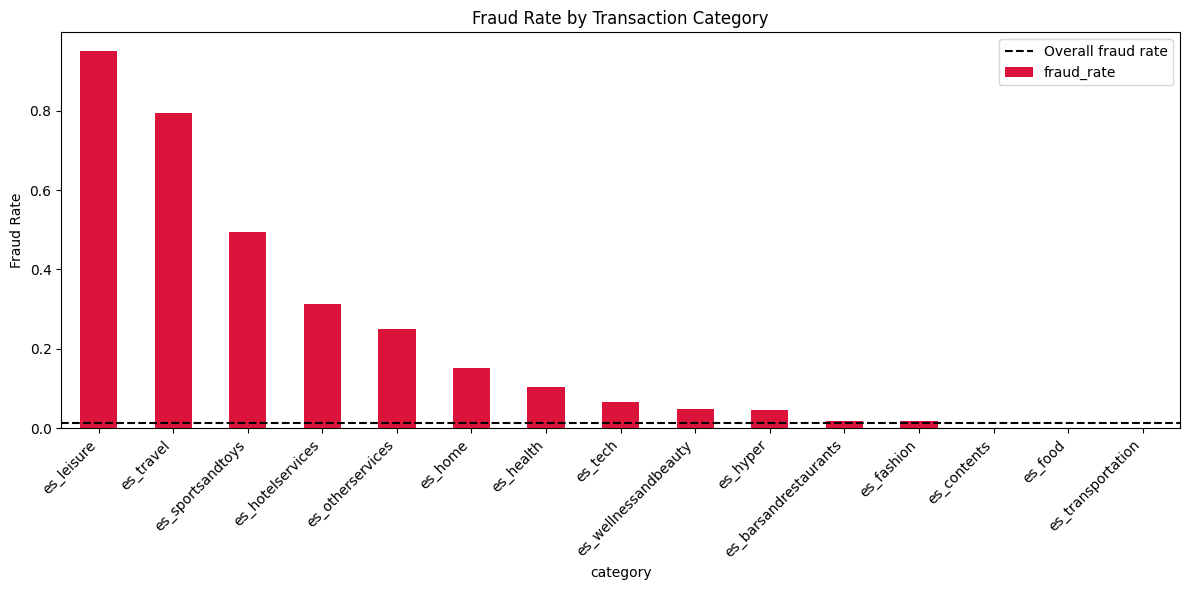

In [19]:
fraud_by_category = df.groupby('category')['fraud'].agg(['mean', 'count']).sort_values('mean', ascending=False)
fraud_by_category.columns = ['fraud_rate', 'transaction_count']
print(fraud_by_category)

plt.figure(figsize=(12, 6))
fraud_by_category['fraud_rate'].plot(kind='bar', color='crimson')
plt.title('Fraud Rate by Transaction Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.axhline(df['fraud'].mean(), color='black', linestyle='--', label='Overall fraud rate')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/04_fraud_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 5: Fraud Rate by Category (Interpretation)

**Interpretation**:
- Category is an exceptionally strong — arguably the single strongest —
  predictor of fraud in this dataset. The fact that fraud is completely
  absent from the three highest-volume categories effectively means the
  classification problem "collapses" for the majority of the data: any
  transaction in `es_transportation`, `es_food`, or `es_contents` can be
  labeled non-fraud with full historical confidence.
- The **actual modeling difficulty is concentrated in a much smaller
  subset** of the data — the remaining ~12 categories (roughly 62,850
  transactions, ~10.5% of the dataset) where fraud rate is non-trivial
  and genuine discrimination between fraud and non-fraud is required.
- High fraud rates in low-volume categories (`es_leisure`, `es_travel`)
  should be interpreted with **caution regarding statistical
  reliability** — a 94.99% fraud rate from only 499 transactions carries
  a much wider margin of error than, say, the 0% rate from 505,119
  transportation transactions. This does not invalidate the finding, but
  it means the estimate could shift somewhat with more data.


##**6. Fraud Rate by Demographics (Age & Gender)**

age
0    0.019576
1    0.011853
2    0.012514
3    0.011928
4    0.012933
5    0.010951
6    0.009748
U    0.005942
Name: fraud, dtype: float64

gender
E    0.005942
F    0.014660
M    0.009073
U    0.000000
Name: fraud, dtype: float64



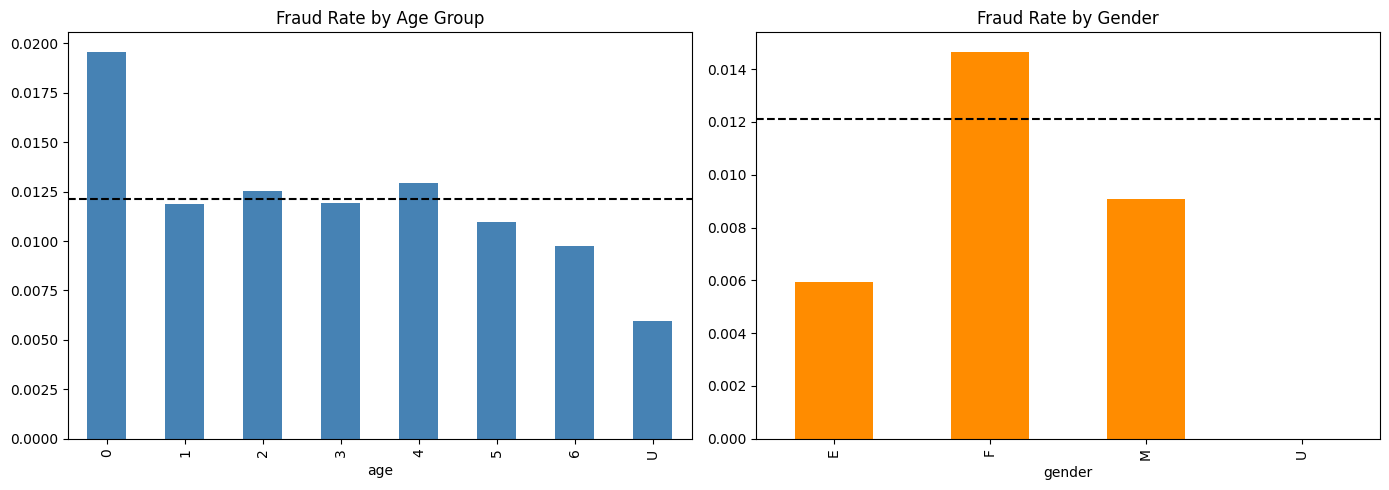

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_fraud = df.groupby('age')['fraud'].mean().sort_index()
age_fraud.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Fraud Rate by Age Group')
axes[0].axhline(df['fraud'].mean(), color='black', linestyle='--')

gender_fraud = df.groupby('gender')['fraud'].mean()
gender_fraud.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Fraud Rate by Gender')
axes[1].axhline(df['fraud'].mean(), color='black', linestyle='--')

print(age_fraud)
print()
print(gender_fraud)
print()
plt.tight_layout()
plt.savefig('outputs/figures/05_fraud_by_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 6: Fraud Rate by Demographics — Age & Gender (Interpretation)

**Result — Gender**: Female customers show a somewhat higher fraud rate
(1.47%) than male customers (0.91%), while `E` (0.59%) and `U` (0%)
represent negligible transaction volumes (1,178 and 515 transactions
respectively) and their rates should not be over-interpreted.

**Interpretation**: Unlike `category` in Section 4 — where fraud rate
ranged from 0% to ~95%, an enormous spread — both `age` and `gender`
show a **narrow range of fraud rates**, all clustered within roughly
0.6–2.0%. This indicates that demographic attributes carry **much
weaker discriminative signal** for fraud compared to transaction
category. Gender shows a mild difference (F ~1.6x

##**7. Amount Distribution  - Fraud vs Non-Fraud**

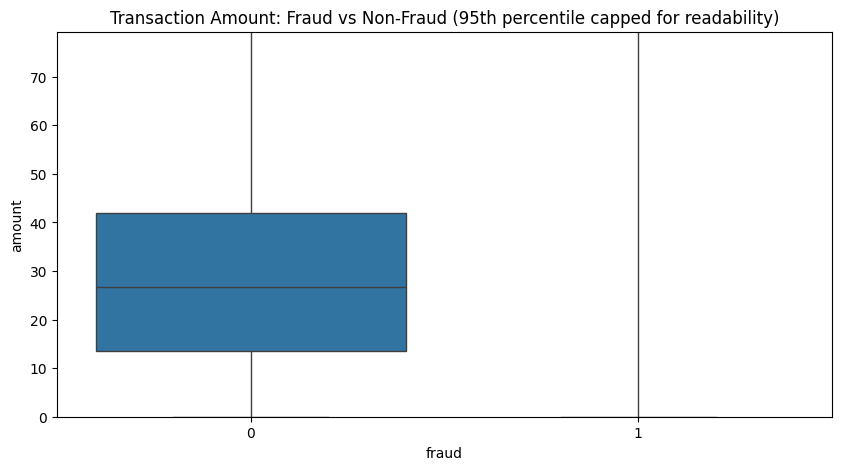

          count        mean         std   min     25%      50%       75%  \
fraud                                                                      
0      587443.0   31.847230   31.470876  0.00   13.59   26.610   41.8950   
1        7200.0  530.926551  835.587112  0.03  159.98  319.175  548.9775   

           max  
fraud           
0      2144.86  
1      8329.96  


In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='fraud', y='amount')
plt.ylim(0, df['amount'].quantile(0.95))
plt.title('Transaction Amount: Fraud vs Non-Fraud (95th percentile capped for readability)')
plt.savefig('outputs/figures/06_amount_by_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('fraud')['amount'].describe())

### Section 7: Amount Distribution — Fraud vs Non-Fraud (Interpretation)

**Interpretation**: `amount` is a strong discriminative feature, with
fraudulent transactions consistently and substantially larger than
legitimate ones. This likely reinforces the category-level signal from
Section 4, as high-fraud-rate categories (`es_leisure`, `es_travel`)
tend to involve higher-ticket purchases.


##**8. Fraud Rate by Merchant (Top Risk Merchants)**

In [24]:
merchant_stats = df.groupby('merchant').agg(
    total_transactions=('fraud', 'count'),
    fraud_count=('fraud', 'sum'),
    fraud_rate=('fraud', 'mean')
).sort_values('fraud_rate', ascending=False)


# from merchants with only 1-2 transactions
merchant_stats_filtered = merchant_stats[merchant_stats['total_transactions'] >= 30]
print(merchant_stats_filtered.head(15))

             total_transactions  fraud_count  fraud_rate
merchant                                                
M1294758098                 191          184    0.963351
M3697346                    308          290    0.941558
M1873032707                 250          216    0.864000
M732195782                  608          518    0.851974
M980657600                 1769         1472    0.832109
M1353266412                  78           64    0.820513
M857378720                  122           92    0.754098
M2080407379                  48           36    0.750000
M2011752106                 244          166    0.680328
M17379832                   282          178    0.631206
M2122776122                 341          200    0.586510
M480139044                 3508         1634    0.465792
M1741626453                 528          196    0.371212
M495352832                   69           24    0.347826
M923029380                  323          102    0.315789


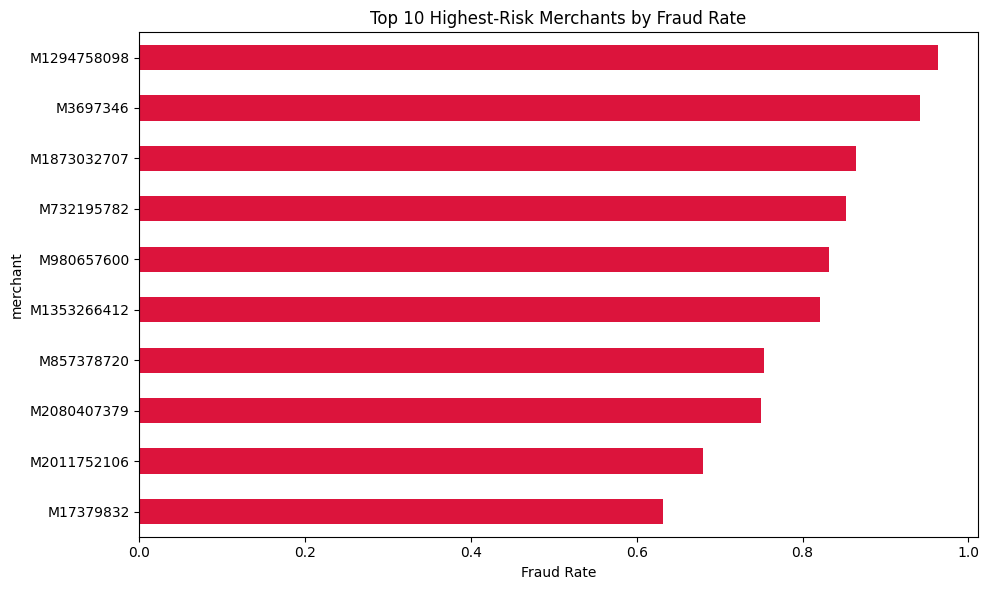

In [28]:
plt.figure(figsize=(10, 6))
merchant_stats_filtered.head(10)['fraud_rate'].plot(kind='barh', color='crimson')
plt.title('Top 10 Highest-Risk Merchants by Fraud Rate')
plt.xlabel('Fraud Rate')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/figures/07_top_risk_merchants.png', dpi=150, bbox_inches='tight')
plt.show()

###Section 8: Fraud Rate by Merchant (Interpretation)

**Interpretation**: Merchant identity carries very strong
discriminative power, comparable to `category`. This is consistent with
Section 4's findings, since these high-risk merchants likely operate
within the high-fraud-rate categories (`es_leisure`, `es_travel`,
`es_sportsandtoys`) already identified. Rather than fraud being
distributed broadly across many merchants, it appears concentrated in a
specific, identifiable set — a pattern that is highly actionable from a
business perspective.



## **9. Temporal Pattern (Fraud Over Step)**

          mean  count
step                 
0     0.016461   2430
1     0.016502   2424
2     0.016247   2462
3     0.016006   2499
4     0.015798   2532
...        ...    ...
175   0.010599   3774
176   0.010750   3721
177   0.010644   3758
178   0.010687   3743
179   0.010785   3709

[180 rows x 2 columns]


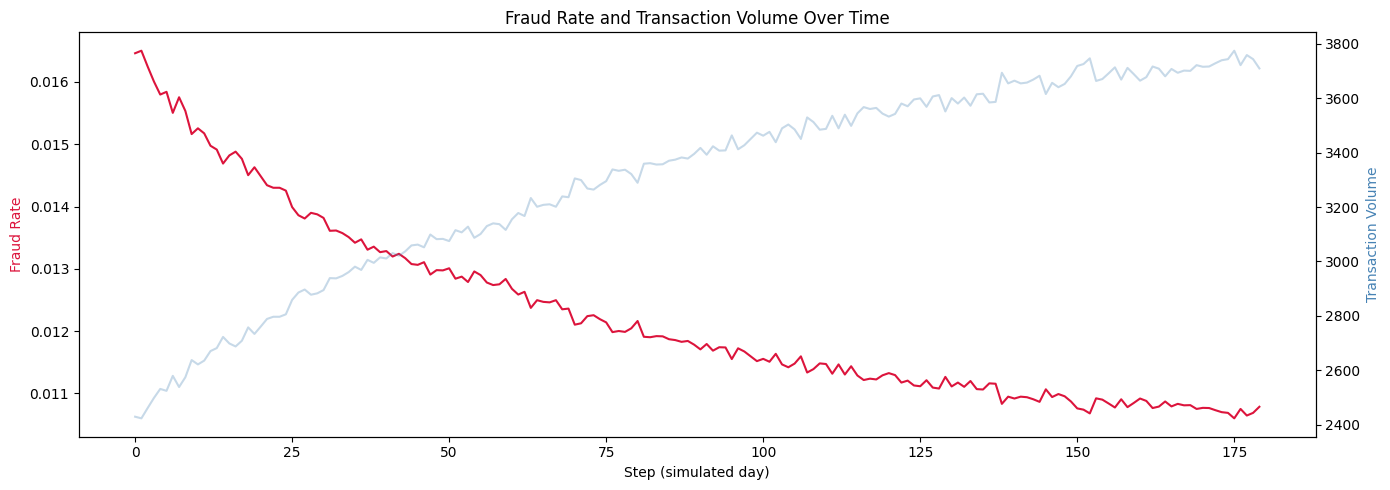

In [27]:
fraud_over_time = df.groupby('step')['fraud'].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(fraud_over_time.index, fraud_over_time['mean'], color='crimson')
ax1.set_ylabel('Fraud Rate', color='crimson')
ax1.set_xlabel('Step (simulated day)')

ax2 = ax1.twinx()
ax2.plot(fraud_over_time.index, fraud_over_time['count'], color='steelblue', alpha=0.3)
ax2.set_ylabel('Transaction Volume', color='steelblue')

print(fraud_over_time)

plt.title('Fraud Rate and Transaction Volume Over Time')
plt.tight_layout()
plt.savefig('outputs/figures/07_fraud_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### Section 9: Temporal Pattern — Fraud Rate over Time (Interpretation)

**Interpretation**: Fraud rate is relatively stable over time, with only
a mild downward drift as overall transaction volume grows — likely
reflecting a slowly expanding customer base rather than any meaningful
time-based fraud pattern (e.g. no evidence of fraud clustering around
specific days or periods). This suggests `step` itself carries weak
standalone signal for fraud prediction.

##**10. Customer Level Behavior Analysis**

In [25]:
customer_stats = df.groupby('customer').agg(
    total_transactions=('fraud', 'count'),
    fraud_count=('fraud', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max')
)
customer_stats['has_fraud'] = customer_stats['fraud_count'] > 0

print(customer_stats['has_fraud'].value_counts())
print(customer_stats.groupby('has_fraud')[['total_transactions', 'avg_amount']].mean())

has_fraud
False    2629
True     1483
Name: count, dtype: int64
           total_transactions  avg_amount
has_fraud                                
False              160.073412   31.740769
True               117.201618   69.435023


### Section 10: Customer-Level Behavior Analysis (Interpretation)

**Interpretation**: More than a third of customers have been exposed to
fraud at least once — a substantially higher proportion than the 1.21%
transaction-level fraud rate would suggest, indicating fraud is not
confined to a tiny isolated group of customers but affects a wide
customer base, even if infrequently per customer. The pattern of fewer
but larger transactions among affected customers aligns with earlier
findings (Sections 6–7): fraud tends to involve higher-value,
lower-frequency transactions, consistent with fraud occurring
opportunistically within an otherwise normal transaction history rather
than defining a customer's overall behavior.

## Section 11: EDA Key Insights Summary

- **Class imbalance**: 1.21% fraud rate — requires SMOTE/class weighting,
  stratified split, and Precision-Recall AUC as the primary metric.
- **Category** is the strongest predictor: fraud rate ranges 0–95% across
  categories; 89.5% of transactions (`es_transportation`, `es_food`,
  `es_contents`) have zero fraud.
- **Merchant** reinforces category signal: a small set of merchants show
  32–96% fraud rates, far above the 1.21% baseline.
- **Amount** is strongly discriminative: fraud averages 530.93 vs. 31.85
  for non-fraud (~16x higher), with minimal distributional overlap.
- **Age and gender** are weak predictors, clustering close to baseline —
  useful only as supporting features.
- **Fraud is customer-widespread**: 36.1% of customers affected at least
  once; affected customers show fewer but larger transactions on average.
- **Time (`step`)** shows no meaningful pattern — mild gradual drift, no
  spikes or cycles; weak standalone predictor.

### Feature Engineering Checklist (Notebook 03)
- `merchant_risk_score`, `category_risk_score` — historical fraud rate encodings
- `amount_log` — address extreme skew
- `customer_avg_amount`, `amount_vs_avg_ratio` — customer-relative anomaly signal
- `customer_txn_count` — transaction frequency
- One-hot encode `age`, `gender` as secondary features
- `step` — likely excluded or minor control variable

### Note for Modeling
Category, merchant, and amount signals overlap substantially and show
unusually clean separation — expect strong metrics, but frame this as a
dataset characteristic rather than a guarantee against more adversarial,
real-world fraud patterns.